In [18]:
# Install necessary libraries
!pip install -q datasets torchvision

import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from torchvision import transforms


In [12]:
print("Fetching Legacy Survey Dataset stream...")
data_stream = load_dataset("MultimodalUniverse/legacysurvey", split="train", streaming=True)

# Fetch the first valid sample
sample = next(iter(data_stream))

print(f"Total fields retrieved: {len(sample)}")
print("Key Metadata:")
for field in ["object_id", "EBV", "SHAPE_R", "SHAPE_E1", "SHAPE_E2"]:
    print(f" - {field}: {sample.get(field)}")

Fetching Legacy Survey Dataset stream...


Resolving data files:   0%|          | 0/165 [00:00<?, ?it/s]

Total fields retrieved: 18
Key Metadata:
 - object_id: b'0421p022-7410'
 - EBV: 0.06657393276691437
 - SHAPE_R: 0.9420995116233826
 - SHAPE_E1: 0.23311986029148102
 - SHAPE_E2: -0.33112043142318726


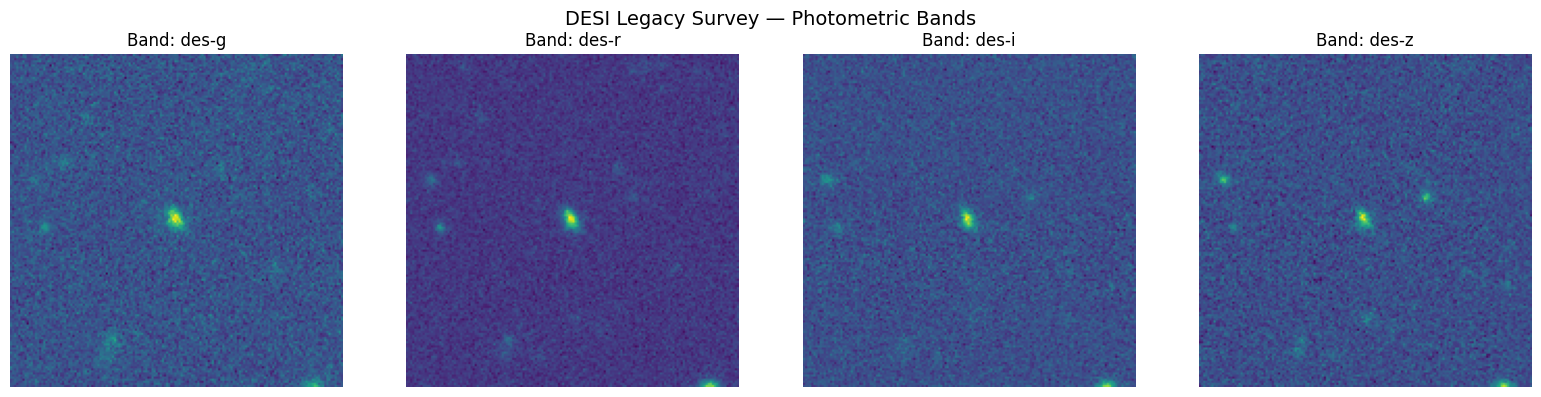

In [13]:
def plot_optical_bands(image_dict):
    """Visualizes the g, r, i, z photometric bands."""
    fluxes = np.array(image_dict["flux"])
    bands = image_dict["band"]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, band, flux in zip(axes, bands, fluxes):
        # Using viridis instead of gray for better contrast on faint sources
        im = ax.imshow(flux, cmap="viridis")
        ax.set_title(f"Band: {band}")
        ax.axis("off")

    plt.suptitle("DESI Legacy Survey — Photometric Bands", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_optical_bands(sample["image"])

In [14]:
# Loading the ViT-Small model from Meta's torch hub
print("Loading DINOv2 ViT-Small model...")
dinov2 = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
dinov2 = dinov2.to(device).eval()
print("Model loaded and set to evaluation mode.")

Loading DINOv2 ViT-Small model...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Model loaded and set to evaluation mode.


In [15]:
# Standard ImageNet normalization expected by DINOv2
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

rgb_image = sample["rgb"]
input_tensor = preprocess(rgb_image).unsqueeze(0).to(device)

# Extract features without tracking gradients
with torch.no_grad():
    features = dinov2.forward_features(input_tensor)

cls_token = features["x_norm_clstoken"]
patch_tokens = features["x_norm_patchtokens"]

print(f"CLS Token Shape (Global representation): {cls_token.shape}")
print(f"Patch Tokens Shape (Spatial features): {patch_tokens.shape}")

CLS Token Shape (Global representation): torch.Size([1, 384])
Patch Tokens Shape (Spatial features): torch.Size([1, 256, 384])


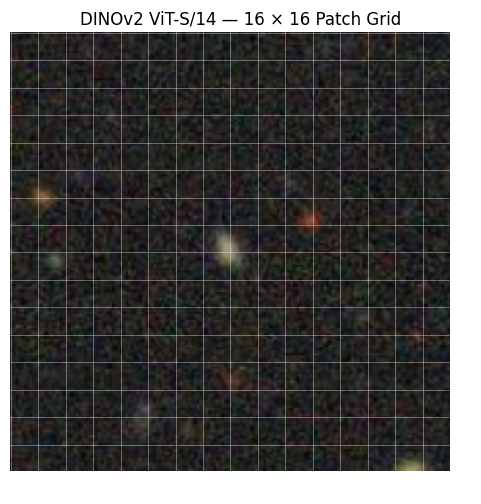

In [16]:
# Display the original preprocessed image
image_to_show = input_tensor[0].cpu().permute(1, 2, 0).numpy()

# Undo ImageNet normalization for visualization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image_to_show = image_to_show * std + mean
image_to_show = np.clip(image_to_show, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(image_to_show)

# Drawing the boundaries
patch_size = 14
image_size = input_tensor.shape[-1]
for i in range(0, image_size + 1, patch_size):
    plt.axhline(i, color='white', linewidth=0.5, alpha=0.5)
    plt.axvline(i, color='white', linewidth=0.5, alpha=0.5)

plt.title("DINOv2 ViT-S/14 — 16 × 16 Patch Grid")
plt.axis("off")
plt.show()

In [17]:
# Initial Embedding exploration
print("CLS token:")
print(cls_token)
print("\nFirst patch token:")
print(patch_tokens[0, 0])
print("\n--------------------------------")

print("CLS token statistics:")
print("Minimum:", cls_token.min().item())
print("Maximum:", cls_token.max().item())
print("Mean:", cls_token.mean().item())
print("Standard deviation:", cls_token.std().item())

print("\nPatch token statistics:")
print("Minimum:", patch_tokens.min().item())
print("Maximum:", patch_tokens.max().item())
print("Mean:", patch_tokens.mean().item())
print("Standard deviation:", patch_tokens.std().item())

CLS token:
tensor([[-1.8138e+00,  1.9696e-01,  5.0432e-01, -6.3987e-01,  1.2943e+00,
          1.1657e+00,  5.1284e+00, -2.3944e+00, -4.8724e+00,  2.0453e+00,
          2.0206e+00, -5.2330e-01, -2.4908e+00, -2.1303e+00,  6.8542e-01,
          4.0538e+00, -3.2509e-01,  5.0003e-02, -4.9351e+00,  2.1751e+00,
         -4.8522e-01,  9.0531e-01, -5.0864e-01, -1.1545e+00, -1.2866e+00,
         -1.1408e+00,  5.4503e-01,  5.7291e-01,  9.6980e-01, -6.4510e-01,
          2.5192e+00,  1.8030e+00, -3.8419e+00,  1.7825e+00,  1.6875e-01,
          2.0335e+00, -2.0447e+00, -3.2368e+00, -3.7307e+00, -1.8005e+00,
          2.7341e+00, -1.8971e+00, -3.0778e+00,  1.6580e+00, -3.9912e-01,
         -1.4360e+00,  1.3985e-01, -1.1111e+00, -6.3052e-01,  3.1827e+00,
         -1.2030e+00,  5.3359e-01,  7.2751e-01,  8.6148e-01,  1.4027e+00,
         -1.1205e+00, -1.0248e+00, -8.9062e-01,  2.2647e-01, -3.4138e+00,
         -1.7774e+00, -2.4277e-01, -3.7247e+00,  2.4334e+00, -3.1661e+00,
         -6.2770e-02,  2.87